# Fit the TSA model to tracked velocity

This uses the 4 V TSA dynamics from `simpleradiusvoltage.ipynb`. Moving mass is payload plus the 10 g carrier plus the transmission. The fit calibrates one effective rotational inertia and one effective load-torque ceiling for each radius. Every third mass is held out as a validation set.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'new_modeling':
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from IPython.display import Image, display
from new_modeling.fit_tracking_model import fit_model, load_tracking_data, run_fit

## Settings

Replace the transmission values with weighed values when available. Each must remain between 5 and 10 g. The midpoint is used by default because velocity alone cannot identify transmission mass separately from effective rotational inertia.

In [2]:
FILTER_WINDOW = 9
FILTER_ORDER = 2
CARRIER_MASS_G = 10.0
TRANSMISSION_MASS_G = {5: 7.5, 7: 7.5, 9: 7.5, 11: 7.5}
OUTPUT_DIR = REPO_ROOT / 'data/model_fit'

,radius_mm,carrier_mass_g,transmission_mass_g,inertia_kg_m2,torque_cap_nm,rmse_m_s,max_error_m_s,cv_inertia_kg_m2,cv_torque_cap_nm,cv_test_rmse_m_s
0,5,10.0,7.5,0.000017,0.078874,0.065318,0.157257,0.000016,0.077982,0.065482
1,7,10.0,7.5,0.000027,0.101359,0.110811,0.276507,0.000027,0.101636,0.081997
2,9,10.0,7.5,0.000023,0.137386,0.088782,0.264481,0.000022,0.135490,0.073598
3,11,10.0,7.5,0.000007,0.106450,0.091339,0.203578,0.000008,0.106658,0.104198


,model,parameter_count,rmse_m_s,max_error_m_s,aic
0,notebook baseline,0,0.669729,1.180839,-67.348139
1,global inertia + torque cap,2,0.428253,1.442472,-138.470891
2,radius inertia + global torque cap,5,0.206410,0.664708,-255.085710
3,radius inertia + radius torque cap,8,0.090513,0.276507,-387.579864


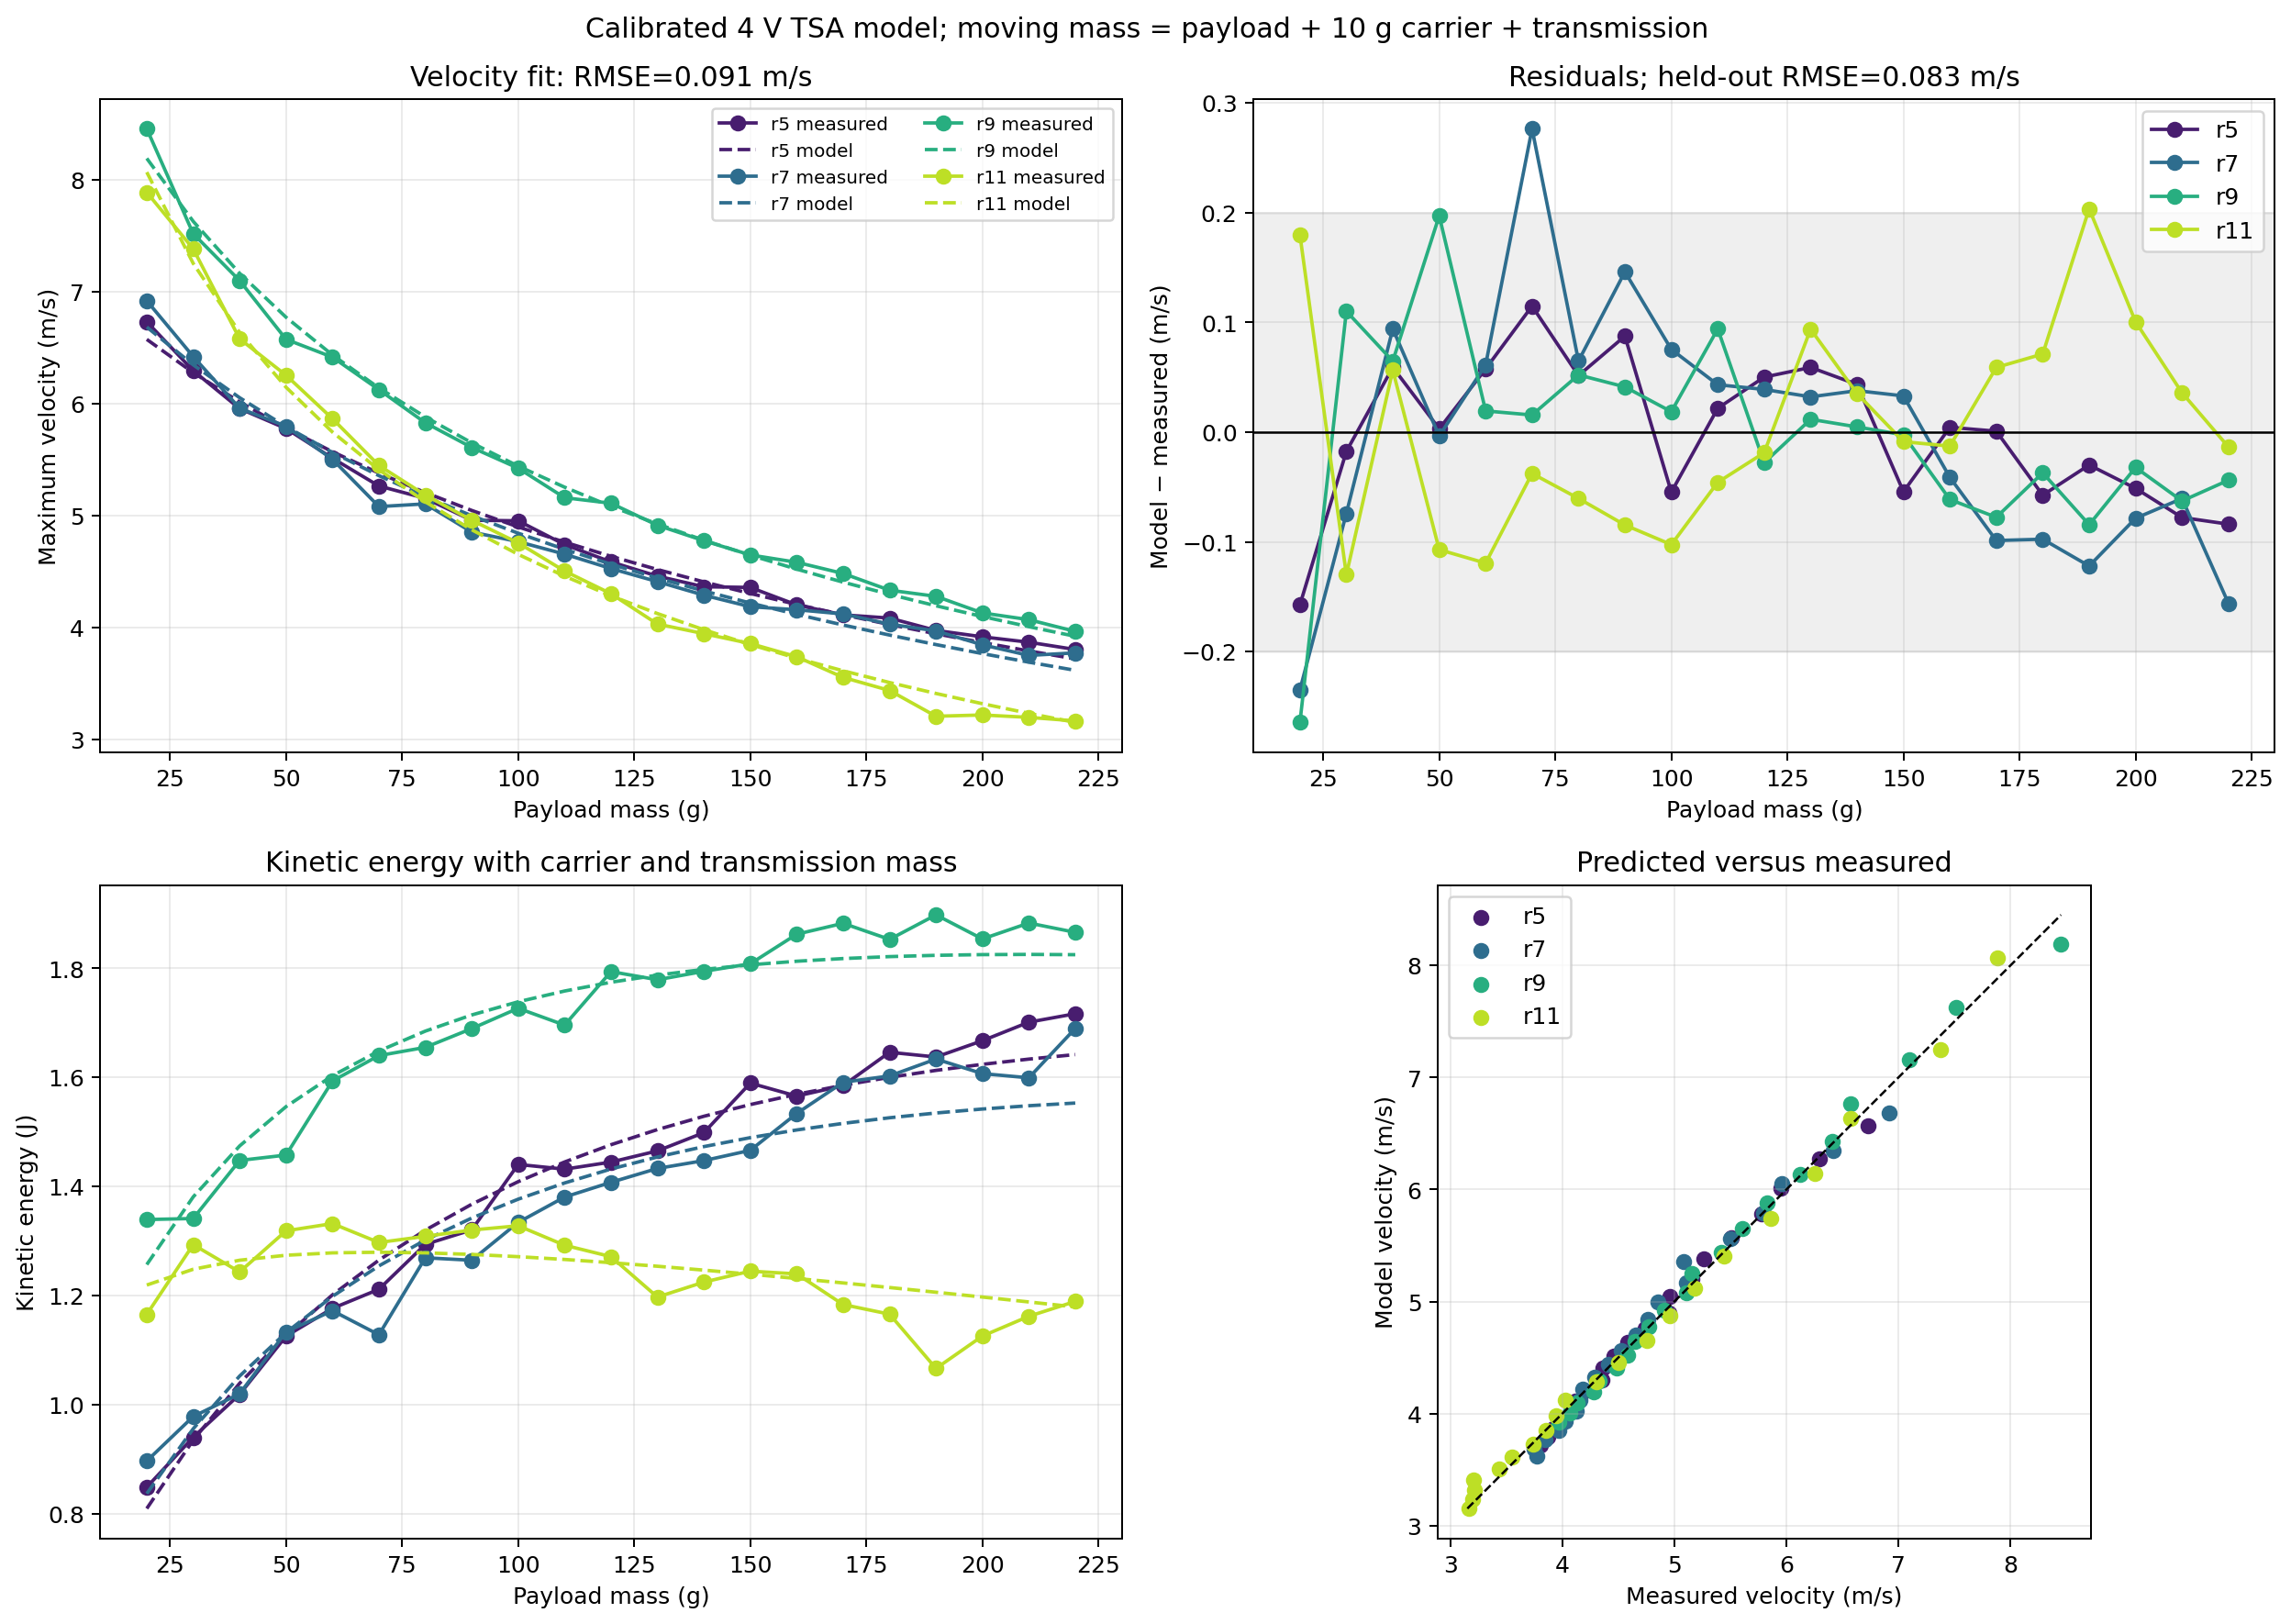

In [3]:
results, parameters, comparison = run_fit(
    filter_window=FILTER_WINDOW,
    filter_order=FILTER_ORDER,
    carrier_mass_g=CARRIER_MASS_G,
    transmission_mass_g=TRANSMISSION_MASS_G,
    output_dir=OUTPUT_DIR,
)

display(parameters.round(6))
display(comparison.round(6))
display(Image(filename=str(OUTPUT_DIR / 'tracking_model_fit.png')))

In [4]:
held_out = results[results['is_cv_holdout']].copy()
held_out['cv_residual_m_s'] = held_out['cv_model_velocity_m_s'] - held_out['measured_velocity_m_s']
held_out[['radius_mm', 'payload_mass_g', 'measured_velocity_m_s', 'cv_model_velocity_m_s', 'cv_residual_m_s']].round(4)

,radius_mm,payload_mass_g,measured_velocity_m_s,cv_model_velocity_m_s,cv_residual_m_s
1,5,30,6.2925,6.2955,0.0030
4,5,60,5.5106,5.5758,0.0652
7,5,90,4.9567,5.0444,0.0877
10,5,120,4.5845,4.6304,0.0460
13,5,150,4.3568,4.2954,-0.0614
16,5,180,4.0830,4.0166,-0.0664
19,5,210,3.8675,3.7794,-0.0881
22,7,30,6.4186,6.3482,-0.0703
25,7,60,5.5006,5.5662,0.0657
28,7,90,4.8512,5.0019,0.1507


## Transmission-mass sensitivity

Refit at both ends of the stated 5–10 g transmission range. If the fit scores stay nearly unchanged, velocity alone cannot distinguish transmission mass from effective rotational inertia.

In [5]:
mass_cases = {
    '5 g each': {5: 5.0, 7: 5.0, 9: 5.0, 11: 5.0},
    '7.5 g each': {5: 7.5, 7: 7.5, 9: 7.5, 11: 7.5},
    '10 g each': {5: 10.0, 7: 10.0, 9: 10.0, 11: 10.0},
}
sensitivity_rows = []
for label, transmission_mass_g in mass_cases.items():
    if transmission_mass_g == TRANSMISSION_MASS_G:
        case_results = results
    else:
        case_data = load_tracking_data(
            FILTER_WINDOW, FILTER_ORDER, CARRIER_MASS_G, transmission_mass_g
        )
        case_results, _, _ = fit_model(case_data)
    held_out = case_results[case_results['is_cv_holdout']]
    sensitivity_rows.append(
        {
            'transmission_case': label,
            'fit_rmse_m_s': np.sqrt(np.mean(case_results['residual_m_s'] ** 2)),
            'held_out_rmse_m_s': np.sqrt(np.mean(
                (held_out['cv_model_velocity_m_s'] - held_out['measured_velocity_m_s']) ** 2
            )),
            'max_error_m_s': case_results['residual_m_s'].abs().max(),
        }
    )
mass_sensitivity = pd.DataFrame(sensitivity_rows)
mass_sensitivity.to_csv(OUTPUT_DIR / 'tracking_model_mass_sensitivity.csv', index=False)
mass_sensitivity.round(4)

,transmission_case,fit_rmse_m_s,held_out_rmse_m_s,max_error_m_s
0,5 g each,0.0905,0.0826,0.2765
1,7.5 g each,0.0905,0.0826,0.2765
2,10 g each,0.0885,0.0824,0.2765
